Rusty Bargain used car sales service is developing an app to attract new customers. In that app, you can quickly find out the market value of your car. You have access to historical data: technical specifications, trim versions, and prices. You need to build the model to determine the value. 

Rusty Bargain is interested in:

- the quality of the prediction;
- the speed of the prediction;
- the time required for training

## Data preparation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import time

In [4]:
df = pd.read_csv('car_data.csv', parse_dates = ['DateCrawled', 'DateCreated', 'LastSeen'])
df.info()

C:\Users\nki46\AppData\Local\Temp\ipykernel_17568\3936398483.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('car_data.csv', parse_dates = ['DateCrawled', 'DateCreated', 'LastSeen'])
C:\Users\nki46\AppData\Local\Temp\ipykernel_17568\3936398483.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('car_data.csv', parse_dates = ['DateCrawled', 'DateCreated', 'LastSeen'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   DateCrawled        354369 non-null  datetime64[ns]
 1   Price              354369 non-null  int64         
 2   VehicleType        316879 non-null  object        
 3   RegistrationYear   354369 non-null  int64         
 4   Gearbox            334536 non-null  object        
 5   Power              354369 non-null  int64         
 6   Model              334664 non-null  object        
 7   Mileage            354369 non-null  int64         
 8   RegistrationMonth  354369 non-null  int64         
 9   FuelType           321474 non-null  object        
 10  Brand              354369 non-null  object        
 11  NotRepaired        283215 non-null  object        
 12  DateCreated        354369 non-null  datetime64[ns]
 13  NumberOfPictures   354369 non-null  int64   

In [5]:
df.columns = df.columns.str.lower()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   datecrawled        354369 non-null  datetime64[ns]
 1   price              354369 non-null  int64         
 2   vehicletype        316879 non-null  object        
 3   registrationyear   354369 non-null  int64         
 4   gearbox            334536 non-null  object        
 5   power              354369 non-null  int64         
 6   model              334664 non-null  object        
 7   mileage            354369 non-null  int64         
 8   registrationmonth  354369 non-null  int64         
 9   fueltype           321474 non-null  object        
 10  brand              354369 non-null  object        
 11  notrepaired        283215 non-null  object        
 12  datecreated        354369 non-null  datetime64[ns]
 13  numberofpictures   354369 non-null  int64   

In [6]:
df= df.rename(columns = {
    'datecrawled': 'date_crawled',
    'vehicletype': 'vehicle_type',
    'registrationyear': 'registration_year',
    'registrationmonth': 'registration_month',
    'fueltype': 'fuel_type',
    'notrepaired':'not_repaired',
    'datecreated':'date_created',
    'numberofpictures':'number_of_pictures',
    'postalcode':'postal_code',
    'lastseen':'last_seen'
})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354369 non-null  datetime64[ns]
 1   price               354369 non-null  int64         
 2   vehicle_type        316879 non-null  object        
 3   registration_year   354369 non-null  int64         
 4   gearbox             334536 non-null  object        
 5   power               354369 non-null  int64         
 6   model               334664 non-null  object        
 7   mileage             354369 non-null  int64         
 8   registration_month  354369 non-null  int64         
 9   fuel_type           321474 non-null  object        
 10  brand               354369 non-null  object        
 11  not_repaired        283215 non-null  object        
 12  date_created        354369 non-null  datetime64[ns]
 13  number_of_pictures  354369 no

In [7]:
df.head()

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:00,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24,0,70435,07/04/2016 03:16
1,2016-03-24 10:58:00,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24,0,66954,07/04/2016 01:46
2,2016-03-14 12:52:00,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14,0,90480,05/04/2016 12:47
3,2016-03-17 16:54:00,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074,17/03/2016 17:40
4,2016-03-31 17:25:00,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,06/04/2016 10:17


In [8]:
# Observing the stats of the numerical columns, specifically the minimum and maximum values
df.describe()

,date_crawled,price,registration_year,power,mileage,registration_month,date_created,number_of_pictures,postal_code
count,354369,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369,354369.0,354369.000000
mean,2016-03-21 12:57:41.165057280,4416.656776,2004.234448,110.094337,128211.172535,5.714645,2016-03-20 19:12:07.753274112,0.0,50508.689087
min,2016-03-05 14:06:00,0.000000,1000.000000,0.000000,5000.000000,0.000000,2014-03-10 00:00:00,0.0,1067.000000
25%,2016-03-13 11:52:00,1050.000000,1999.000000,69.000000,125000.000000,3.000000,2016-03-13 00:00:00,0.0,30165.000000
50%,2016-03-21 17:50:00,2700.000000,2003.000000,105.000000,150000.000000,6.000000,2016-03-21 00:00:00,0.0,49413.000000
75%,2016-03-29 14:37:00,6400.000000,2008.000000,143.000000,150000.000000,9.000000,2016-03-29 00:00:00,0.0,71083.000000
max,2016-04-07 14:36:00,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,2016-04-07 00:00:00,0.0,99998.000000
std,NaN,4514.158514,90.227958,189.850405,37905.341530,3.726421,NaN,0.0,25783.096248


In [9]:
# Observing missing data
df_missing = df.isna().sum()
print(df_missing)

date_crawled              0
price                     0
vehicle_type          37490
registration_year         0
gearbox               19833
power                     0
model                 19705
mileage                   0
registration_month        0
fuel_type             32895
brand                     0
not_repaired          71154
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64


In [10]:
# Missing percentages
percentage_missing = (df_missing/df.shape[0])*100
print(percentage_missing)

date_crawled           0.000000
price                  0.000000
vehicle_type          10.579368
registration_year      0.000000
gearbox                5.596709
power                  0.000000
model                  5.560588
mileage                0.000000
registration_month     0.000000
fuel_type              9.282697
brand                  0.000000
not_repaired          20.079070
date_created           0.000000
number_of_pictures     0.000000
postal_code            0.000000
last_seen              0.000000
dtype: float64


In [11]:
# Number of duplicates
df.duplicated().sum()

262

In [12]:
# Observing unique values to ensure there are no errors
df['brand'].unique()

array(['volkswagen', 'audi', 'jeep', 'skoda', 'bmw', 'peugeot', 'ford',
       'mazda', 'nissan', 'renault', 'mercedes_benz', 'opel', 'seat',
       'citroen', 'honda', 'fiat', 'mini', 'smart', 'hyundai',
       'sonstige_autos', 'alfa_romeo', 'subaru', 'volvo', 'mitsubishi',
       'kia', 'suzuki', 'lancia', 'toyota', 'chevrolet', 'dacia',
       'daihatsu', 'trabant', 'saab', 'chrysler', 'jaguar', 'daewoo',
       'porsche', 'rover', 'land_rover', 'lada'], dtype=object)

In [13]:
df['registration_year'].sort_values().unique()

array([1000, 1001, 1039, 1111, 1200, 1234, 1253, 1255, 1300, 1400, 1500,
       1600, 1602, 1688, 1800, 1910, 1915, 1919, 1920, 1923, 1925, 1927,
       1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938,
       1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950,
       1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961,
       1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972,
       1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983,
       1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994,
       1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2066, 2200, 2222, 2290, 2500, 2800, 2900, 3000,
       3200, 3500, 3700, 3800, 4000, 4100, 4500, 4800, 5000, 5300, 5555,
       5600, 5900, 5911, 6000, 6500, 7000, 7100, 7500, 7800, 8000, 8200,
       8455, 8500, 8888, 9000, 9229, 9450, 9996, 99

In [14]:
df['vehicle_type'].unique()

array([nan, 'coupe', 'suv', 'small', 'sedan', 'convertible', 'bus',
       'wagon', 'other'], dtype=object)

In [15]:
df['gearbox'].unique()

array(['manual', 'auto', nan], dtype=object)

In [16]:
df['power'].sort_values().unique()

array([    0,     1,     2,     3,     4,     5,     6,     7,     8,
           9,    10,    11,    12,    13,    14,    15,    16,    17,
          18,    19,    20,    21,    22,    23,    24,    25,    26,
          27,    28,    29,    30,    31,    32,    33,    34,    35,
          36,    37,    38,    39,    40,    41,    42,    43,    44,
          45,    46,    47,    48,    49,    50,    51,    52,    53,
          54,    55,    56,    57,    58,    59,    60,    61,    62,
          63,    64,    65,    66,    67,    68,    69,    70,    71,
          72,    73,    74,    75,    76,    77,    78,    79,    80,
          81,    82,    83,    84,    85,    86,    87,    88,    89,
          90,    91,    92,    93,    94,    95,    96,    97,    98,
          99,   100,   101,   102,   103,   104,   105,   106,   107,
         108,   109,   110,   111,   112,   113,   114,   115,   116,
         117,   118,   119,   120,   121,   122,   123,   124,   125,
         126,   127,

In [17]:
print('Unique Models: ',df['model'].sort_values().unique())
print()
print('Unique Registration Months: ',df['registration_month'].sort_values().unique())
print('Unique Fuel Types: ',df['fuel_type'].sort_values().unique())
print()
print('Unique Not Repaired: ',df['not_repaired'].sort_values().unique())

Unique Models:  ['100' '145' '147' '156' '159' '1_reihe' '1er' '200' '2_reihe' '300c'
 '3_reihe' '3er' '4_reihe' '500' '5_reihe' '5er' '601' '6_reihe' '6er'
 '7er' '80' '850' '90' '900' '9000' '911' 'a1' 'a2' 'a3' 'a4' 'a5' 'a6'
 'a8' 'a_klasse' 'accord' 'agila' 'alhambra' 'almera' 'altea' 'amarok'
 'antara' 'arosa' 'astra' 'auris' 'avensis' 'aveo' 'aygo' 'b_klasse'
 'b_max' 'beetle' 'berlingo' 'bora' 'boxster' 'bravo' 'c1' 'c2' 'c3' 'c4'
 'c5' 'c_klasse' 'c_max' 'c_reihe' 'caddy' 'calibra' 'captiva' 'carisma'
 'carnival' 'cayenne' 'cc' 'ceed' 'charade' 'cherokee' 'citigo' 'civic'
 'cl' 'clio' 'clk' 'clubman' 'colt' 'combo' 'cooper' 'cordoba' 'corolla'
 'corsa' 'cr_reihe' 'croma' 'crossfire' 'cuore' 'cx_reihe' 'defender'
 'delta' 'discovery' 'doblo' 'ducato' 'duster' 'e_klasse' 'elefantino'
 'eos' 'escort' 'espace' 'exeo' 'fabia' 'fiesta' 'focus' 'forester'
 'forfour' 'fortwo' 'fox' 'freelander' 'fusion' 'g_klasse' 'galant'
 'galaxy' 'getz' 'gl' 'glk' 'golf' 'grand' 'i3' 'i_reihe' 'ibi

## Observations

Upon inspecting the data set, I first noticed that the columns' naming conventions were not in snake case, so that was the first change made. Then, I used `df.describe()` to inspect the minimum and maximum values of the numerical columns to spot signs of anomalies. Doing so allowed me to spot the following:

- `price` minimum value is 0
- `power` minimum value is 0
- `registration_year` minimum value is 1000
- `registration_month` minimum value is 0
- `number_of_pictures` all values are 0

After further inspection, I found that most of the columns above have other suspicious values that will need to be treated. I also found that the dataset has a lot of missing data, `vehicle_type` being the highest, with about 20% of its values missing.

In [19]:
# Dropping duplicates
df = df.drop_duplicates()
df.duplicated().sum()

0

In [20]:
# Changing some of the model names to reduce redundancy
model_map = {
    '1_reihe': '1_series', '1er': '1_series', 'serie_1': '1_series',
    '3_reihe': '3_series', '3er': '3_series', 'serie_3': '3_series', 
    '5_reihe': '5_series', '5er': '5_series', 'serie_5': '5_series',
    '6_reihe': '6_series', '6er': '6_series',
    '7er': '7_series', '7_reihe': '7_series',
    'x_reihe': 'x_series',
    'z_reihe': 'z_series',

    'a_klasse': 'a_class',
    'b_klasse': 'b_class',
    'c_klasse': 'c_class',
    'e_klasse': 'e_class',
    's_klasse': 's_class',
    'm_klasse': 'm_class',
    'g_klasse': 'g_class',
    'v_klasse': 'v_class',

    'mx_reihe': 'mx_series',
    'rx_reihe': 'rx_series',
    'cx_reihe': 'cx_series',

    'kaefer': 'beetle',

    'range_rover_sport': 'range_rover',
    'range_rover_evoque': 'range_rover',
    'rangerover': 'range_rover',
}
df['model']= df['model'].map(model_map).fillna(df['model'])

In [21]:
df['model'].sort_values().unique()

array(['100', '145', '147', '156', '159', '1_series', '200', '2_reihe',
       '300c', '3_series', '4_reihe', '500', '5_series', '601',
       '6_series', '7_series', '80', '850', '90', '900', '9000', '911',
       'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a8', 'a_class', 'accord',
       'agila', 'alhambra', 'almera', 'altea', 'amarok', 'antara',
       'arosa', 'astra', 'auris', 'avensis', 'aveo', 'aygo', 'b_class',
       'b_max', 'beetle', 'berlingo', 'bora', 'boxster', 'bravo', 'c1',
       'c2', 'c3', 'c4', 'c5', 'c_class', 'c_max', 'c_reihe', 'caddy',
       'calibra', 'captiva', 'carisma', 'carnival', 'cayenne', 'cc',
       'ceed', 'charade', 'cherokee', 'citigo', 'civic', 'cl', 'clio',
       'clk', 'clubman', 'colt', 'combo', 'cooper', 'cordoba', 'corolla',
       'corsa', 'cr_reihe', 'croma', 'crossfire', 'cuore', 'cx_series',
       'defender', 'delta', 'discovery', 'doblo', 'ducato', 'duster',
       'e_class', 'elefantino', 'eos', 'escort', 'espace', 'exeo',
       'fabia', '

In [22]:
# Changing the columns to categorical data types 
cat_columns= ['vehicle_type','gearbox', 'model', 'fuel_type', 'brand', 'not_repaired', 'postal_code'  ]
df[cat_columns]= df[cat_columns].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354107 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354107 non-null  datetime64[ns]
 1   price               354107 non-null  int64         
 2   vehicle_type        316623 non-null  category      
 3   registration_year   354107 non-null  int64         
 4   gearbox             334277 non-null  category      
 5   power               354107 non-null  int64         
 6   model               334406 non-null  category      
 7   mileage             354107 non-null  int64         
 8   registration_month  354107 non-null  int64         
 9   fuel_type           321218 non-null  category      
 10  brand               354107 non-null  category      
 11  not_repaired        282962 non-null  category      
 12  date_created        354107 non-null  datetime64[ns]
 13  number_of_pictures  354107 non-nul

In [23]:
# Filling in categorical missing data with an 'unknown' marker
for category in cat_columns:
    df[category]= df[category].cat.add_categories('unknown').fillna('unknown')

df['vehicle_type'].sort_values().unique()

['bus', 'convertible', 'coupe', 'other', 'sedan', 'small', 'suv', 'wagon', 'unknown']
Categories (9, object): ['bus', 'convertible', 'coupe', 'other', ..., 'small', 'suv', 'wagon', 'unknown']

In [24]:
# Range of years the vehicle profiles were created
print('Earliest profiles were created in:', min(df['date_created'].dt.year), '\nLatest profiles were created in:',max(df['date_created'].dt.year))

Earliest profiles were created in: 2014 
Latest profiles were created in: 2016


In [25]:
# Inspecting data with suspicious registration years
years_filter= (df['registration_year'] < 1950) | (df['registration_year'] > 2016)
df[years_filter].head(10)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
15,2016-03-11 21:39:00,450,small,1910,unknown,0,ka,5000,0,petrol,ford,unknown,2016-03-11,0,24148,19/03/2016 08:46
22,2016-03-23 14:52:00,2900,unknown,2018,manual,90,meriva,150000,5,petrol,opel,no,2016-03-23,0,49716,31/03/2016 01:16
26,2016-03-10 19:38:00,5555,unknown,2017,manual,125,c4,125000,4,unknown,citroen,no,2016-03-10,0,31139,16/03/2016 09:16
48,2016-03-25 14:40:00,7750,unknown,2017,manual,80,golf,100000,1,petrol,volkswagen,unknown,2016-03-25,0,48499,31/03/2016 21:47
51,2016-03-07 18:57:00,2000,unknown,2017,manual,90,punto,150000,11,gasoline,fiat,yes,2016-03-07,0,66115,07/03/2016 18:57
57,2016-03-10 20:53:00,2399,unknown,2018,manual,64,other,125000,3,unknown,seat,no,2016-03-10,0,33397,25/03/2016 10:17
65,2016-03-28 17:41:00,10900,unknown,2017,manual,101,astra,50000,3,unknown,opel,no,2016-03-28,0,63607,06/04/2016 23:15
111,2016-03-19 18:40:00,0,unknown,2017,manual,0,golf,5000,12,petrol,volkswagen,unknown,2016-03-19,0,21698,01/04/2016 08:47
155,2016-03-09 12:53:00,14500,unknown,2017,manual,136,sportage,125000,5,gasoline,kia,no,2016-03-09,0,49696,05/04/2016 23:45
163,2016-04-04 12:57:00,1200,unknown,2018,manual,75,astra,150000,0,unknown,opel,no,2016-04-04,0,15344,06/04/2016 14:45


A lot of the registration years are extremely suspicious. Some of the dates are very old, and some are well into the future. Keeping in mind that these are used vehicles, it's impossible for them to be registered after their profiles were created. I am deciding to filter out data before 1950, an arbitrarily chosen year, and data after 2016, the latest year of profile creation. Any data outside of these dates will be made into missing values, or NaNs. 

In [27]:
years_replaced = df.loc[years_filter, 'registration_year'] = np.nan
df['registration_year'].sort_values().unique()

array([1950., 1951., 1952., 1953., 1954., 1955., 1956., 1957., 1958.,
       1959., 1960., 1961., 1962., 1963., 1964., 1965., 1966., 1967.,
       1968., 1969., 1970., 1971., 1972., 1973., 1974., 1975., 1976.,
       1977., 1978., 1979., 1980., 1981., 1982., 1983., 1984., 1985.,
       1986., 1987., 1988., 1989., 1990., 1991., 1992., 1993., 1994.,
       1995., 1996., 1997., 1998., 1999., 2000., 2001., 2002., 2003.,
       2004., 2005., 2006., 2007., 2008., 2009., 2010., 2011., 2012.,
       2013., 2014., 2015., 2016.,   nan])

In [28]:
# Placing quantile caps on the power column to filter out horsepower anomalies; will re-fit on train later
df.loc[df['power'] == 0, 'power'] = np.nan 
low, high = df['power'].quantile([0.01, 0.995])
df.loc[df['power'] < low, 'power'] = np.nan
df.loc[df['power'] > high, 'power'] = np.nan

In [29]:
df['power'].sort_values().unique()

array([ 45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
        67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
        78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
        89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
       100., 101., 102., 103., 104., 105., 106., 107., 108., 109., 110.,
       111., 112., 113., 114., 115., 116., 117., 118., 119., 120., 121.,
       122., 123., 124., 125., 126., 127., 128., 129., 130., 131., 132.,
       133., 134., 135., 136., 137., 138., 139., 140., 141., 142., 143.,
       144., 145., 146., 147., 148., 149., 150., 151., 152., 153., 154.,
       155., 156., 157., 158., 159., 160., 161., 162., 163., 164., 165.,
       166., 167., 168., 169., 170., 171., 172., 173., 174., 175., 176.,
       177., 178., 179., 180., 181., 182., 183., 184., 185., 186., 187.,
       188., 189., 190., 191., 192., 193., 194., 19

In [30]:
# Replacing the registration month 0 with NaN
df.loc[df['registration_month']== 0, 'registration_month']= np.nan
df['registration_month'].sort_values().unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., nan])

In [31]:
# Dropping this column
df = df.drop('number_of_pictures', axis=1)
df.columns

Index(['date_crawled', 'price', 'vehicle_type', 'registration_year', 'gearbox',
       'power', 'model', 'mileage', 'registration_month', 'fuel_type', 'brand',
       'not_repaired', 'date_created', 'postal_code', 'last_seen'],
      dtype='object')

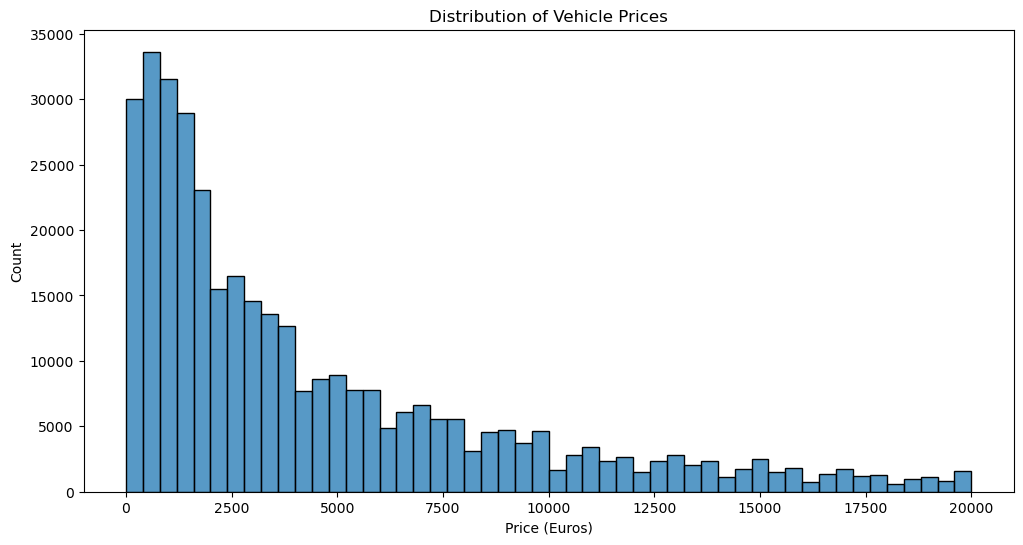

In [32]:
# Observing the distribution of vehicle prices
plt.figure(figsize= (12,6))
sns.histplot(data= df['price'], bins= 50)
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price (Euros)')
plt.show()

In [33]:
# Observing the percentage of prices equal to zero
price_zero = df['price']== 0
(len(df[price_zero]['price'])/len(df))*100

3.041453571942944

In [34]:
# Removing those entries
df = df[df['price'] > 0]
df.shape

(343337, 15)

In [35]:
# Replacing extreme values in the 'price' column with lower and upper boundaries
upper, lower = df['price'].quantile([0.01, 0.99])
df['price']= df['price'].clip(lower,upper)

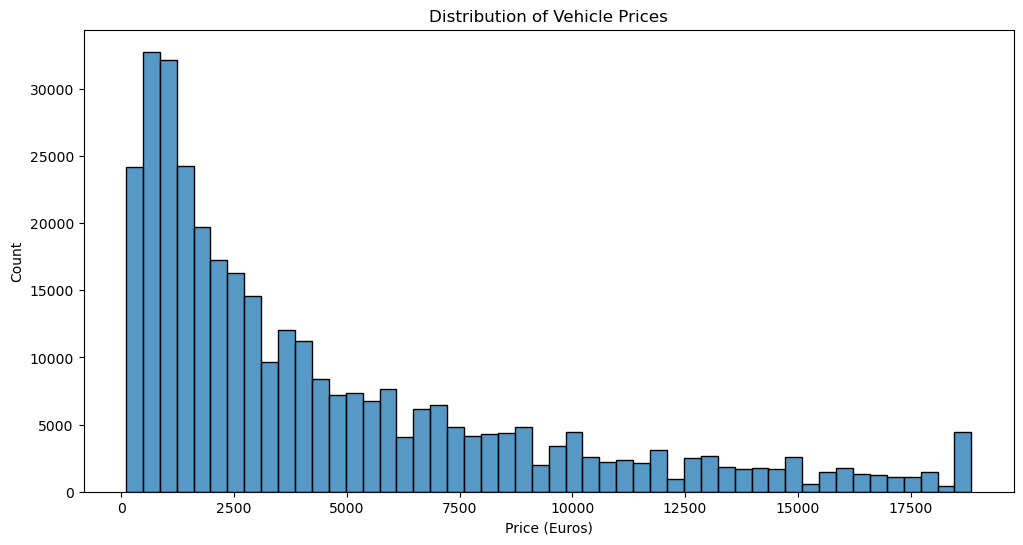

In [36]:
# Reviewing the changes
plt.figure(figsize= (12,6))
sns.histplot(data= df['price'], bins= 50)
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price (Euros)')
plt.show()

In [37]:
df['price'].describe()

count    343337.000000
mean       4548.823812
std        4492.834702
min         100.000000
25%        1200.000000
50%        2890.000000
75%        6500.000000
max       18850.000000
Name: price, dtype: float64

## The Cleaning Process

After observing the data set, the data cleaning process began. It included the following:

- Dropping duplicates.
- Changing model names like 'rangerover' to reduce redundancy.
- Changing categories to their respective data types.
- Missing categories were marked as 'unknown'.
- Registration years were filtered using a choice of 1950 as the earliest boundary and the `date_created` years as the latest; anything above or below those bounds was marked as 'NaN'.
- Horsepower values were capped using lower and upper quantile boundaries. Anything outside those bounds was made NaN.
- Registration months equal to zero were marked as 'NaN'.
- The `number_of_pictures` column only contained zeroes, so it was dropped.
- After observing the `price` column, prices equal to zero were likely an error, and they made up only 3% of the column's total data, so they were dropped.
- Lastly, quantile caps were placed on the rest of the values, making anything below the 1 percentile equal to the lowest cap and anything above the 99th percentile equal to the highest.

## Model training

In [40]:
# Splitting the features and target
target= df['price']
features= df.drop(columns=['date_crawled','last_seen', 'date_created', 'postal_code'])

In [41]:
cat_features = ['vehicle_type', 'gearbox', 'model', 'fuel_type', 'brand', 'not_repaired']
num_features = ['registration_year', 'registration_month', 'power', 'mileage']

In [42]:
# creating the training/validation splits, imputing any data missed during the cleaning process, and scaling and encoding necessary columns
features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size= 0.2, random_state= 42)

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

In [43]:
linreg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [44]:
linreg_model.fit(features_train, target_train)
predictions = linreg_model.predict(features_valid)
rmse = mean_squared_error(target_valid, predictions, squared=False)
print(f"Linear Regression RMSE: {rmse:.2f}")

Linear Regression RMSE: 2677.71


### Linear Regression Results
- RMSE: 2677.71

The linear regression model has an RMSE of about **2,678 Euros**. This will serve as a benchmark for other models. If their results show no improvement, then something is wrong.

In [46]:
# Decision Tree 
dtree = DecisionTreeRegressor(max_depth=10, random_state=42)
dtree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', dtree)
])

start = time.time()
dtree_model.fit(features_train, target_train)
end = time.time()

predictions = dtree_model.predict(features_valid)

rmse = mean_squared_error(target_valid, predictions, squared=False)
print(f"Decision Tree RMSE: {rmse:.2f}")
print(f"Training + prediction time: {end - start:.2f} seconds")

Decision Tree RMSE: 2109.11
Training + prediction time: 15.19 seconds


### Decision Tree Results
- RMSE: 2109.11
- Training time: ~ 4.3 seconds

The Decision Tree is showing an improvement in being able to learn the relationships within the data at a fast pace. This is a good sign so far. 

In [ ]:
# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,  
    max_depth=20,      
    random_state=42,
    n_jobs=-1          
)

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', rf)
])

start = time.time()
rf_model.fit(features_train, target_train)
end = time.time()

predictions = rf_model.predict(features_valid)

rmse = mean_squared_error(target_valid, predictions, squared=False)
print(f"Random Forest RMSE: {rmse:.2f}")
print(f"Training + prediction time: {end - start:.2f} seconds")

### Random Forest Results
- RMSE: 1665.07
- Training time: ~ 872 seconds (≈15 minutes)

While Random Forest achieved the best accuracy so far, it took significantly longer to train compared to Decision Tree and Linear Regression. This highlights a trade-off between accuracy and speed, which will be further explored with gradient boosting models.

In [ ]:
# LightGBM 

lgbm = LGBMRegressor(
    n_estimators=600,        
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_model = Pipeline([
    ('preprocessor', preprocessor), 
    ('regressor', lgbm)
])

start = time.time()
lgbm_model.fit(features_train, target_train)
train_time = time.time() - start

preds = lgbm_model.predict(features_valid)
rmse = mean_squared_error(target_valid, preds, squared=False)
print(f"LightGBM RMSE: {rmse:.2f}")
print(f"Training + prediction time: {train_time:.2f} s")

## Model analysis

- **Target:** `price` (EUR)  
- **Metric:** RMSE (lower is better)  
- **Process:** scikit-learn `Pipeline` (impute, scale numerics for LR, OHE categoricals) applied to both train and validation splits; models differ only in the final regressor.  
- **Speed:** `.fit()` + `.predict()` on the validation set.

| Model | Key Settings | Valid RMSE (€) | Train + Predict Time |
|---|---|---:|---:|
| Linear Regression | `Pipeline`: SimpleImputer + StandardScaler (num), OHE (cat) | **2677.71** | *fast* |
| Decision Tree Regressor | `max_depth=10`, `random_state=42` | **2109.11** | **4.3 s** |
| Random Forest Regressor | `n_estimators=100`, `max_depth=20`, `n_jobs=-1`, `random_state=42` | **1665.07** | **872 s** |
| LightGBM Regressor | `n_estimators=600`, `learning_rate=0.05`, `num_leaves=63`, `subsample=0.8`, `colsample_bytree=0.8`, `random_state=42` | **1636.34** | **16 s** |

## Summary
- **Linear Regression** serves as a sanity check; all tree/boosting models outperform it.  
- **Decision Tree** captures nonlinearity but is outperformed by ensembles.  
- **Random Forest** improves accuracy substantially but at a **large computational cost** on this data size.  
- **LightGBM** offers the **best quality–speed trade-off**, aligning with the project’s focus on **prediction quality, prediction speed, and training time**.